# Chapter 43 — Logarithms Intuition

> **Prerequisites:** ch041 (Exponents and Powers), ch042 (Exponential Growth), ch026 (Real Numbers)  
> **You will learn:**
> - What a logarithm *is* — as a question, not a formula
> - The three standard bases: log₂ (computing), log₁₀ (scale), ln (analysis)
> - The laws of logarithms as direct consequences of the laws of exponents
> - Why `O(log n)` algorithms are so desirable
> - How to compute logarithms from scratch using the bisection method
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

A logarithm answers a specific question: **"what exponent do I need?"**

```
2^? = 8     →  ? = 3       →  log₂(8) = 3
10^? = 1000 →  ? = 3       →  log₁₀(1000) = 3
e^? = 7.389 →  ? ≈ 2       →  ln(7.389) ≈ 2
```

Formally: `logᵦ(x) = y` means `b^y = x`.

The logarithm is the **inverse function** of exponentiation *(introduced in ch041)*. Just as subtraction undoes addition, and division undoes multiplication, the logarithm undoes the exponential:

```
b^(logᵦ(x)) = x          # exponent undoes log
logᵦ(b^y)   = y          # log undoes exponent
```

**Three standard bases:**
- `log₂(x)`: how many bits (binary digits) to represent `x` values. Used in algorithm analysis.
- `log₁₀(x)`: the "order of magnitude" of `x`. Used in decibels, pH, Richter scale.
- `ln(x)` (natural log, base `e`): the "right" base for calculus and continuous models.

**Common misconception:** `log(x²) ≠ (log x)²`. The first is `2 log x`; the second squares the logarithm. These are completely different operations. Students confuse the position of the exponent.

---

## 2. Intuition & Mental Models

**Physical analogy:** Think of the logarithm as a *zoom-out lens*. Exponential functions zoom in on differences between large numbers. The logarithm zooms out — it compresses vast ranges into manageable scales. The difference between `1,000,000` and `1,000,000,000` (a factor of 1000) becomes `6 vs 9` on a log scale.

**Computational analogy:** Think of `log₂(n)` as the number of times you can halve `n` before reaching 1. Binary search halves the search space each step — so it takes `log₂(n)` steps to find an element in `n` items. This is precisely why `O(log n)` algorithms are so fast: doubling the input adds only one step.

**Recall from ch042:** We had `P(t) = P₀ e^(kt)`. To *solve for t* — "when does the population reach level `P`?" — we need logarithms:
```
P = P₀ e^(kt)
P/P₀ = e^(kt)
ln(P/P₀) = kt
t = ln(P/P₀) / k
```
The logarithm is the tool that solves exponential equations.

**Change of base:** All logarithms are proportional to each other:
```
logᵦ(x) = ln(x) / ln(b)
```
So the *shape* of all logarithm functions is the same — just vertically scaled.

---

## 3. Visualization

C:\Users\user\AppData\Local\Temp\ipykernel_13204\1232925593.py:37: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_13204\1232925593.py:37: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_13204\1232925593.py:37: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarni

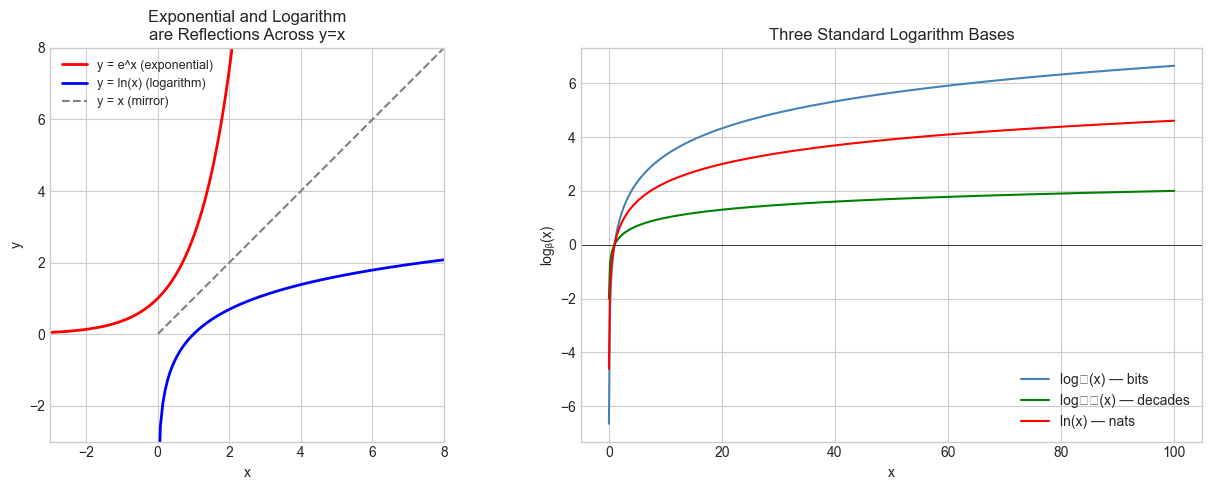

In [1]:
# --- Visualization: Logarithm as inverse of exponential ---
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

x_exp = np.linspace(-3, 3, 300)
x_log = np.linspace(0.01, 20, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: e^x and ln(x) are reflections across y=x
ax = axes[0]
ax.plot(x_exp, np.exp(x_exp), color='red',   label='y = e^x (exponential)', linewidth=2)
ax.plot(x_log, np.log(x_log), color='blue',  label='y = ln(x) (logarithm)', linewidth=2)
ax.plot(x_log, x_log,         color='gray',  label='y = x (mirror)',         linestyle='--')
ax.set_xlim(-3, 8)
ax.set_ylim(-3, 8)
ax.set_aspect('equal')
ax.set_title('Exponential and Logarithm\nare Reflections Across y=x')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(fontsize=9)

# Panel 2: Three log bases on the same plot
ax = axes[1]
x_pos = np.linspace(0.01, 100, 500)
ax.plot(x_pos, np.log2(x_pos),  color='steelblue', label='log₂(x) — bits')
ax.plot(x_pos, np.log10(x_pos), color='green',     label='log₁₀(x) — decades')
ax.plot(x_pos, np.log(x_pos),   color='red',       label='ln(x) — nats')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Three Standard Logarithm Bases')
ax.set_xlabel('x')
ax.set_ylabel('logᵦ(x)')
ax.legend()

plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_13204\4116227249.py:34: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_13204\4116227249.py:34: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


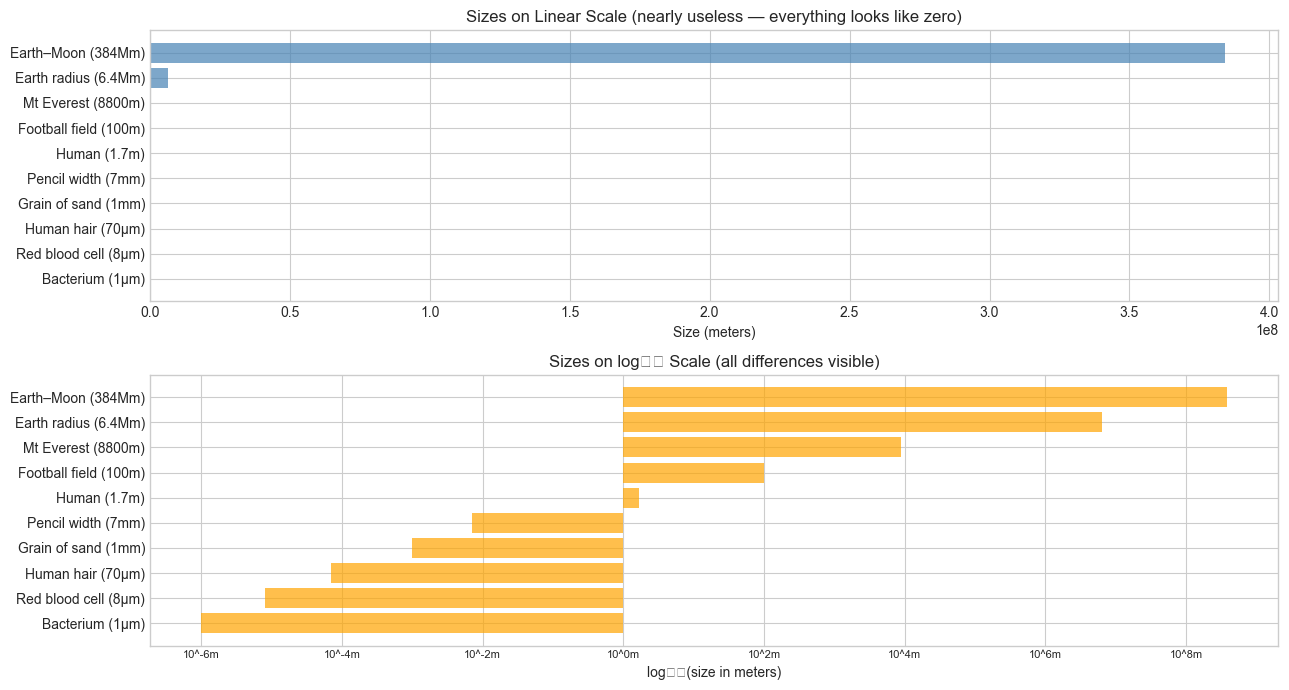

In [2]:
# --- Visualization: Logarithmic compression — the zoom-out effect ---
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Real-world quantities spanning many orders of magnitude
LABELS = [
    'Bacterium (1μm)', 'Red blood cell (8μm)', 'Human hair (70μm)',
    'Grain of sand (1mm)', 'Pencil width (7mm)', 'Human (1.7m)',
    'Football field (100m)', 'Mt Everest (8800m)', 'Earth radius (6.4Mm)',
    'Earth–Moon (384Mm)'
]
VALUES_M = [1e-6, 8e-6, 70e-6, 1e-3, 7e-3, 1.7, 100, 8800, 6.4e6, 3.84e8]

fig, axes = plt.subplots(2, 1, figsize=(13, 7))

ax = axes[0]
ax.barh(LABELS, VALUES_M, color='steelblue', alpha=0.7)
ax.set_title('Sizes on Linear Scale (nearly useless — everything looks like zero)')
ax.set_xlabel('Size (meters)')

ax = axes[1]
log_values = np.log10(VALUES_M)
ax.barh(LABELS, log_values, color='orange', alpha=0.7)
ax.set_title('Sizes on log₁₀ Scale (all differences visible)')
ax.set_xlabel('log₁₀(size in meters)')

# Add tick labels in real units
ticks = range(-6, 9, 2)
ax.set_xticks(ticks)
ax.set_xticklabels([f'10^{t}m' for t in ticks], fontsize=8)

plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

### Definition

```
logᵦ(x) = y    ⟺    b^y = x

Where:
  b > 0, b ≠ 1    (base)
  x > 0           (argument — logarithm undefined for x ≤ 0)
  y ∈ ℝ           (result — the exponent)
```

### Laws of logarithms

Each law is the mirror image of a law of exponents *(from ch041)*:

```
Law of exponents          →  Law of logarithms
─────────────────────────────────────────────────
b^m × b^n = b^(m+n)      →  logᵦ(xy)  = logᵦ(x) + logᵦ(y)
b^m / b^n = b^(m-n)      →  logᵦ(x/y) = logᵦ(x) - logᵦ(y)
(b^m)^n   = b^(mn)       →  logᵦ(x^p) = p × logᵦ(x)
```

### Change of base formula

```
logᵦ(x) = ln(x) / ln(b) = log₁₀(x) / log₁₀(b)
```

This means computing `log₂` using only `ln`:
```python
log2_x = np.log(x) / np.log(2)   # equivalent to np.log2(x)
```

### Special values

```
logᵦ(1)   = 0      (b^0 = 1 always)
logᵦ(b)   = 1      (b^1 = b always)
logᵦ(b^n) = n      (definition)
logᵦ(x) → -∞ as x → 0⁺   (logarithm blows up downward at 0)
logᵦ(x) → +∞ as x → ∞    (grows without bound, but slowly)
```

In [3]:
# --- Verify laws of logarithms numerically ---
import numpy as np

x, y, p = 12.0, 7.0, 3.0
b = 2.0  # base

def logb(val, base):
    return np.log(val) / np.log(base)

print("Laws of Logarithms — Numerical Verification  (b=2, x=12, y=7, p=3)")
print("-" * 65)

# Law 1
lhs = logb(x * y, b)
rhs = logb(x, b) + logb(y, b)
print(f"1. log(xy)  = log(x)+log(y):  {lhs:.6f} == {rhs:.6f}  {'✓' if np.isclose(lhs,rhs) else '✗'}")

# Law 2
lhs = logb(x / y, b)
rhs = logb(x, b) - logb(y, b)
print(f"2. log(x/y) = log(x)-log(y): {lhs:.6f} == {rhs:.6f}  {'✓' if np.isclose(lhs,rhs) else '✗'}")

# Law 3
lhs = logb(x**p, b)
rhs = p * logb(x, b)
print(f"3. log(x^p) = p·log(x):      {lhs:.6f} == {rhs:.6f}  {'✓' if np.isclose(lhs,rhs) else '✗'}")

# Change of base
log2_direct = np.log2(x)
log2_change = np.log(x) / np.log(2)
print(f"\nChange of base: log₂({x}) direct={log2_direct:.6f}  via ln={log2_change:.6f}  {'✓' if np.isclose(log2_direct,log2_change) else '✗'}")

Laws of Logarithms — Numerical Verification  (b=2, x=12, y=7, p=3)
-----------------------------------------------------------------
1. log(xy)  = log(x)+log(y):  6.392317 == 6.392317  ✓
2. log(x/y) = log(x)-log(y): 0.777608 == 0.777608  ✓
3. log(x^p) = p·log(x):      10.754888 == 10.754888  ✓

Change of base: log₂(12.0) direct=3.584963  via ln=3.584963  ✓


---

## 5. Python Implementation

In [ ]:
# --- Implementation: Computing logarithms from scratch via bisection ---
#
# We cannot use np.log. We find log_b(x) by solving b^y = x for y.
# Since b^y is strictly increasing in y (for b>1), we can binary-search for y.

def log_bisection(x, base, tol=1e-10, max_iter=200):
    """
    Compute log_base(x) by binary search on y such that base^y = x.

    This works because f(y) = base^y is strictly monotone, so we
    can bisect for the root of f(y) - x = 0.

    Args:
        x:        positive real number (argument)
        base:     base > 1
        tol:      tolerance for convergence
        max_iter: maximum bisection steps

    Returns:
        Approximate log_base(x)
    """
    if x <= 0:
        raise ValueError("Logarithm undefined for x <= 0")
    if base <= 0 or base == 1:
        raise ValueError("Base must be positive and not 1")

    # Find initial bracket [lo, hi] such that base^lo < x < base^hi
    lo, hi = -1000.0, 1000.0
    # Shrink the bracket (optional but faster)
    while True:
        try:
            if base ** lo <= x:
                break
        except OverflowError:
            # underflow means base**lo is effectively 0, which is < x
            break
        lo *= 2

    while True:
        try:
            if base ** hi >= x:
                break
        except OverflowError:
            # overflow means base**hi is effectively +inf, which is > x
            break
        hi *= 2

    # Binary search
    for _ in range(max_iter):
        mid = (lo + hi) / 2
        val = base ** mid
        if abs(val - x) < tol * x:  # relative tolerance
            return mid
        if val < x:
            lo = mid
        else:
            hi = mid

    return (lo + hi) / 2


# Validate against numpy
import numpy as np

test_cases = [(8, 2), (1000, 10), (1, 2), (0.125, 2), (np.e**3, np.e)]
print(f"{'x':>10} {'base':>6} {'bisection':>14} {'numpy':>14} {'error':>12}")
print("-" * 60)
for x, b in test_cases:
    our   = log_bisection(x, b)
    ref   = np.log(x) / np.log(b)
    err   = abs(our - ref)
    print(f"{x:>10.4f} {b:>6.4f} {our:>14.8f} {ref:>14.8f} {err:>12.2e}")

---

## 6. Experiments

C:\Users\user\AppData\Local\Temp\ipykernel_13204\4002598296.py:35: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


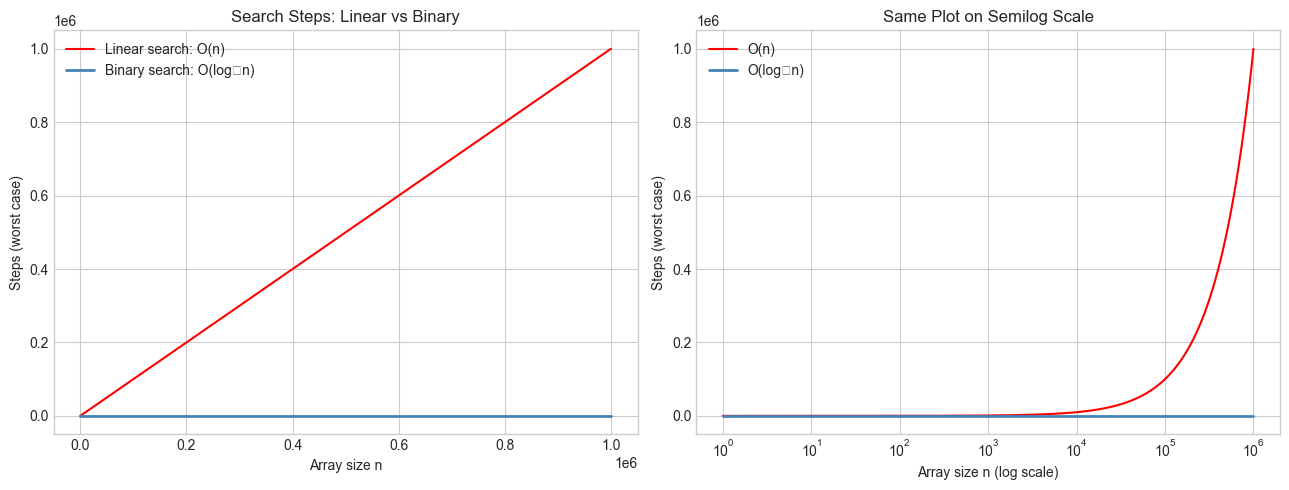

n=         100: linear=         100 steps, binary search= 6 steps
n=       1,000: linear=       1,000 steps, binary search= 9 steps
n=   1,000,000: linear=   1,000,000 steps, binary search=19 steps
n=1,000,000,000: linear=1,000,000,000 steps, binary search=29 steps


In [8]:
# --- Experiment 1: O(log n) vs O(n) — binary search step counts ---
# Hypothesis: Binary search takes log₂(n) steps while linear search takes n steps.
# The difference becomes staggering as n grows.
# Try changing: MAX_N

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

MAX_N = 1_000_000   # <-- modify this

n_values = np.logspace(0, np.log10(MAX_N), 400)
linear_steps = n_values
log_steps    = np.log2(n_values)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(n_values, linear_steps, color='red',       label='Linear search: O(n)')
ax.plot(n_values, log_steps,    color='steelblue', label='Binary search: O(log₂n)', linewidth=2)
ax.set_title('Search Steps: Linear vs Binary')
ax.set_xlabel('Array size n')
ax.set_ylabel('Steps (worst case)')
ax.legend()

ax = axes[1]
ax.semilogx(n_values, linear_steps, color='red',       label='O(n)')
ax.semilogx(n_values, log_steps,    color='steelblue', label='O(log₂n)', linewidth=2)
ax.set_title('Same Plot on Semilog Scale')
ax.set_xlabel('Array size n (log scale)')
ax.set_ylabel('Steps (worst case)')
ax.legend()

plt.tight_layout()
plt.show()

for n in [100, 1_000, 1_000_000, 1_000_000_000]:
    print(f"n={n:>12,}: linear={n:>12,} steps, binary search={int(np.log2(n)):>2} steps")

In [9]:
# --- Experiment 2: Where does log₂(n) equal n? ---
# Hypothesis: log₂(n) < n for all n > 1. Find the crossover numerically.
# Also: the boundary log₂(n!) vs n² via Stirling's approximation.
# Try changing: BASE

import numpy as np

BASE = 2.0  # <-- modify this (try 3.0, 10.0, np.e)

print(f"Comparing log_{BASE}(n) vs n:")
print(f"{'n':>10} {'log_b(n)':>12} {'n':>12} {'log<n':>8}")
print("-" * 46)
for n in [0.1, 0.5, 1, 2, 4, 10, 100, 1000]:
    logval = np.log(n) / np.log(BASE)
    print(f"{n:>10.3f} {logval:>12.4f} {n:>12.4f} {str(logval < n):>8}")

# For base > 1, log_b(n) < n for all n > 1. But log can exceed n for n < 1.
print(f"\nConclusion: log_{BASE}(n) < n for n > 1 (log grows much slower)")

Comparing log_2.0(n) vs n:
         n     log_b(n)            n    log<n
----------------------------------------------
     0.100      -3.3219       0.1000     True
     0.500      -1.0000       0.5000     True
     1.000       0.0000       1.0000     True
     2.000       1.0000       2.0000     True
     4.000       2.0000       4.0000     True
    10.000       3.3219      10.0000     True
   100.000       6.6439     100.0000     True
  1000.000       9.9658    1000.0000     True

Conclusion: log_2.0(n) < n for n > 1 (log grows much slower)


In [10]:
# --- Experiment 3: Real-world decibels and pH — log scales in practice ---
# Hypothesis: Adding 10 dB doesn't add 10 to the power — it multiplies by 10.
# Try changing: POWER_WATTS to explore the dB scale

import numpy as np

P_REFERENCE = 1e-12  # reference power in watts (threshold of human hearing)

print("Sound Pressure Levels (dB = 10 × log₁₀(P / P_ref))")
print("-" * 50)
sounds = {
    'Threshold of hearing': 1e-12,
    'Whisper':              1e-10,
    'Normal conversation':  1e-6,
    'Vacuum cleaner':       1e-4,
    'Rock concert':         1e-1,
    'Jet engine (nearby)':  1e2,
}
for label, power in sounds.items():
    dB = 10 * np.log10(power / P_REFERENCE)
    print(f"{label:30s}: {power:.1e} W  →  {dB:6.1f} dB")

print("\n+10 dB means power × 10. +20 dB means power × 100. +3 dB ≈ power × 2.")
print("This compression is only legible because of the logarithm.")

Sound Pressure Levels (dB = 10 × log₁₀(P / P_ref))
--------------------------------------------------
Threshold of hearing          : 1.0e-12 W  →     0.0 dB
Whisper                       : 1.0e-10 W  →    20.0 dB
Normal conversation           : 1.0e-06 W  →    60.0 dB
Vacuum cleaner                : 1.0e-04 W  →    80.0 dB
Rock concert                  : 1.0e-01 W  →   110.0 dB
Jet engine (nearby)           : 1.0e+02 W  →   140.0 dB

+10 dB means power × 10. +20 dB means power × 100. +3 dB ≈ power × 2.
This compression is only legible because of the logarithm.


---

## 7. Exercises

**Easy 1.** Without Python, compute: `log₂(64)`, `log₁₀(0.001)`, `ln(e⁵)`, `log₃(81)`. Verify in Python using only `np.log` and the change-of-base formula.

**Easy 2.** The Richter scale measures earthquake energy logarithmically: a magnitude-7 quake is 10× more energetic than magnitude-6. How many times more energetic is magnitude 9 than magnitude 6? Write the formula and compute.

**Medium 1.** Extend `log_bisection` to handle fractional bases (e.g., base 0.5) and verify that `log₀.₅(0.125) = 3`.

**Medium 2.** Implement `log2_via_squaring(x)`: compute `log₂(x)` without `np.log` by repeatedly squaring the argument. *(Hint: if `x > 2`, you can subtract 1 from the result and halve `x`. If `x < 1`, the log is negative.)*

**Hard.** Derive the product rule for logarithms from the definition. That is, starting only from `logᵦ(x) = y ⟺ b^y = x` and the product rule for exponents `b^(m+n) = b^m × b^n`, prove that `logᵦ(xy) = logᵦ(x) + logᵦ(y)` for all `x, y > 0`.

---

## 8. Mini Project: Detecting Exponential Growth from Data

In [ ]:
# --- Mini Project: Log-linearization as a diagnostic tool ---
#
# Problem:
#   Given a dataset of (time, value) pairs, determine whether the growth is
#   linear, polynomial (quadratic), or exponential — using logarithms.
#
#   Key insight:
#     - Exponential:  log(y) is linear in x         → plot log(y) vs x
#     - Power law:    log(y) is linear in log(x)    → plot log(y) vs log(x)
#     - Linear:       y is linear in x (no transform needed)
#
# Dataset: Three synthetic series with noise.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(7)

t = np.linspace(1, 20, 50)
noise = lambda scale: np.random.normal(0, scale, len(t))

# Three datasets
y_linear = 3 * t + 5           + noise(3)
y_power  = 2 * t**2.3          + noise(t**2.3 * 0.05)
y_exp    = 5 * np.exp(0.2 * t) + noise(5 * np.exp(0.2 * t) * 0.05)

# TODO 1: For each dataset, plot:
#   (a) y vs t (raw)
#   (b) log(y) vs t (semi-log: linearizes exponential)
#   (c) log(y) vs log(t) (log-log: linearizes power law)
# Identify which transform makes each dataset look most linear.

fig, axes = plt.subplots(3, 3, figsize=(14, 11))
datasets = [('Linear: 3t+5',  y_linear, 'green'),
            ('Power: 2t^2.3', y_power,  'blue'),
            ('Exponential: 5e^0.2t', y_exp, 'red')]

for row, (title, y, color) in enumerate(datasets):
    # Raw
    axes[row, 0].scatter(t, y, s=15, color=color, alpha=0.7)
    axes[row, 0].set_title(f'{title}\nRaw: y vs t')
    axes[row, 0].set_xlabel('t')
    axes[row, 0].set_ylabel('y')

    # Semi-log: log(y) vs t
    axes[row, 1].scatter(t, np.log(np.maximum(y, 1e-9)), s=15, color=color, alpha=0.7)
    axes[row, 1].set_title(f'Semi-log: log(y) vs t')
    axes[row, 1].set_xlabel('t')
    axes[row, 1].set_ylabel('log(y)')

    # Log-log: log(y) vs log(t)
    axes[row, 2].scatter(np.log(t), np.log(np.maximum(y, 1e-9)), s=15, color=color, alpha=0.7)
    axes[row, 2].set_title(f'Log-log: log(y) vs log(t)')
    axes[row, 2].set_xlabel('log(t)')
    axes[row, 2].set_ylabel('log(y)')

plt.suptitle('Identifying Growth Type via Log Transformations', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# TODO 2: For the exponential dataset, fit a line to log(y) vs t
# and recover the growth rate k and initial value P0.
log_y_exp = np.log(y_exp)
coeffs = np.polyfit(t, log_y_exp, 1)
k_est  = coeffs[0]
P0_est = np.exp(coeffs[1])
print(f"Exponential fit from log-linearization:")
print(f"  Estimated k:  {k_est:.4f}  (true: 0.2000)")
print(f"  Estimated P₀: {P0_est:.4f}  (true: 5.0000)")

---

## 9. Chapter Summary & Connections

- The logarithm answers: "what exponent produces this value?" It is the inverse of exponentiation.
- Three bases dominate: log₂ (computing), log₁₀ (scale), ln (analysis). All are proportional via the change-of-base formula.
- Laws of logarithms are the direct mirror of laws of exponents: products become sums, powers become products.
- `O(log n)` complexity means: doubling the input adds one operation. This is why binary search and balanced tree lookups are so efficient.
- Log-transforming exponential data converts a curve to a line — the key technique for parameter estimation from data.

**Backward connection:** This chapter is the formal inverse of ch041 (Exponents and Powers) and ch042 (Exponential Growth). The bisection method used in the implementation reuses the binary-halving idea from ch041's fast exponentiation.

**Forward connections:**
- ch044 (Logarithmic Scales) applies log₁₀ and log₂ to measurement, signal processing, and complexity analysis with full visualization.
- ch045 (Computational Logarithms) will implement `ln` from scratch using Taylor series *(previewed in ch219 — Taylor Series)*.
- The natural logarithm is the antiderivative of `1/x` — this becomes precise in ch222 (Integration Intuition), and is central to computing entropy in ch278 (Information Theory) and KL divergence in ch279.